# Reproduce Results for NER Deliverable
Members: Miki, Jose, Lluc

In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), 'utils'))

import utils
import pickle
import torch
import torch.nn as nn
import numpy as np

## 1. Load Data

In [2]:
test_sents = utils.load_data('data/test_data_ner.csv')
tiny_test_sents = utils.load_data('data/tiny_test.csv')
print(f"Loaded {len(test_sents)} test sentences and {len(tiny_test_sents)} tiny test sentences.")

Loaded 38367 test sentences and 13 tiny test sentences.


## 2. Evaluate CRF Model

--- CRF Model Evaluation ---
Accuracy (excluding 'O'): 0.6484
F1-score (weighted): 0.9384


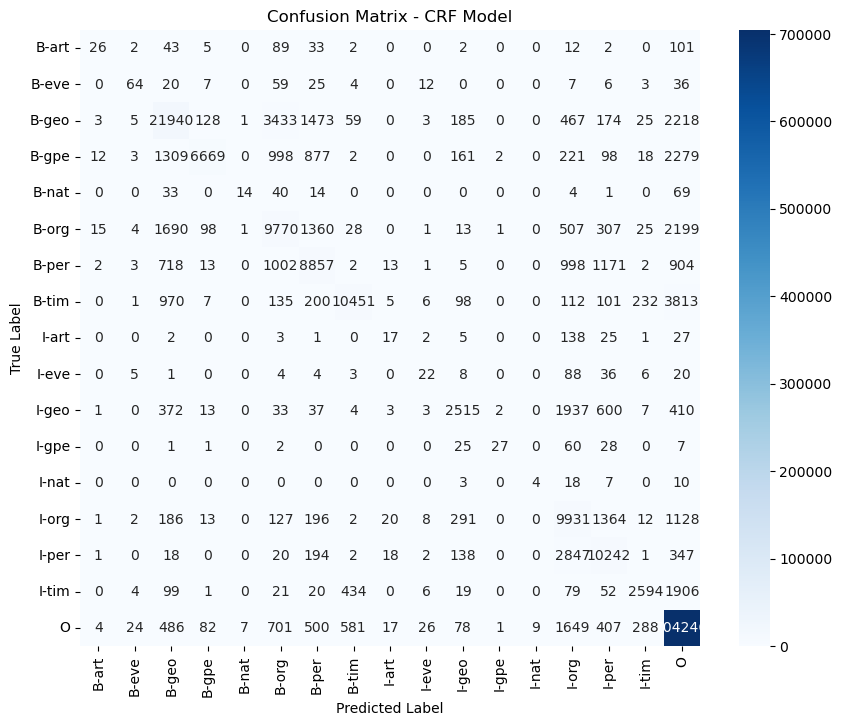

(0.6483744433960057, 0.9383748011074365)

In [3]:
with open('fitted_models/crf_model.pkl', 'rb') as f:
    crf = pickle.load(f)

X_test = [utils.sent2features(s) for s in test_sents]
y_test = [utils.sent2labels(s) for s in test_sents]
y_pred_crf = crf.predict(X_test)

utils.evaluate_model(y_test, y_pred_crf, model_name="CRF Model")

## 3. Evaluate BiLSTM Model

--- BiLSTM Model Evaluation ---
Accuracy (excluding 'O'): 0.3330
F1-score (weighted): 0.8725


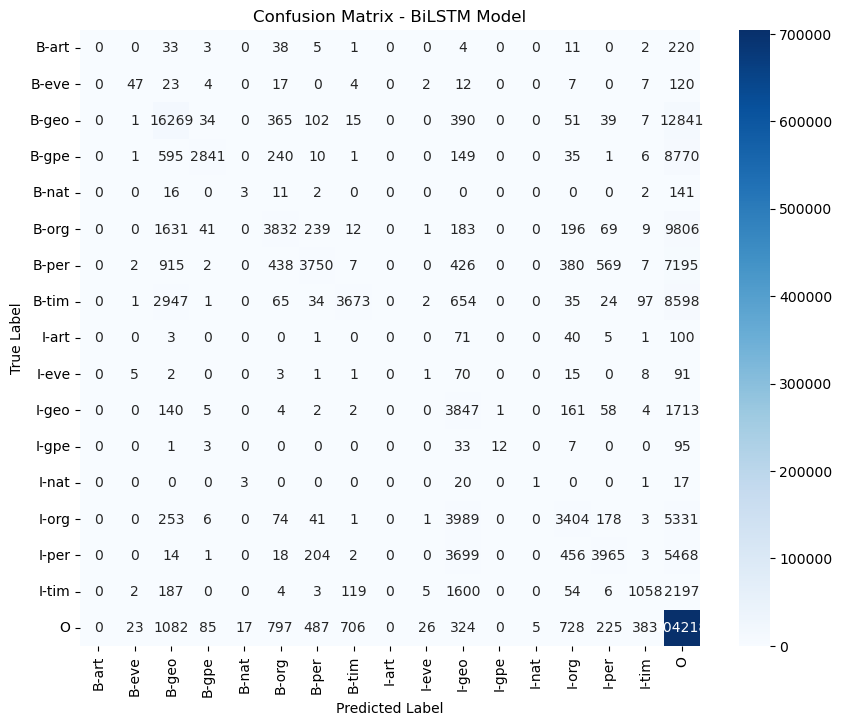

(0.3330110034078591, 0.8725030347653046)

In [4]:
with open('fitted_models/dl_mappings.pkl', 'rb') as f:
    mappings = pickle.load(f)
word_to_ix = mappings['word_to_ix']
tag_to_ix = mappings['tag_to_ix']
ix_to_tag = mappings['ix_to_tag']

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, tagset_size, embedding_dim=50, hidden_dim=50):
        super(BiLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.hidden2tag = nn.Linear(hidden_dim * 2, tagset_size)
        
    def forward(self, x):
        embeds = self.embedding(x)
        lstm_out, _ = self.lstm(embeds)
        tag_space = self.hidden2tag(lstm_out)
        return tag_space

model = BiLSTM(len(word_to_ix), len(tag_to_ix))
model.load_state_dict(torch.load('fitted_models/bilstm_model.pth'))
model.eval()

def predict_dl(sents):
    preds = []
    with torch.no_grad():
        for sent in sents:
            words = [word_to_ix.get(w, word_to_ix["<UNK>"]) for w, t in sent]
            inputs = torch.tensor(words).unsqueeze(0)
            outputs = model(inputs)
            pred_tags = torch.argmax(outputs, dim=-1).squeeze(0).tolist()
            preds.append([ix_to_tag.get(p, "O") for p in pred_tags])
    return preds

y_pred_dl = predict_dl(test_sents)
utils.evaluate_model(y_test, y_pred_dl, model_name="BiLSTM Model")

## 4. TINY TEST Results

TINY TEST PREDICTIONS (CRF):
The/O programmers/O from/O Barcelona/B-geo might/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
The/O programmers/O from/O Barchelona/B-geo cannot/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
Jack/B-per London/I-per went/O to/O Parris/B-geo ./O
Jack/B-per London/I-per went/O to/O Paris/B-geo ./O
Bill/B-per gates/O and/O Steve/B-per jobs/O never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
Bill/B-per Gates/I-per and/O Steve/B-per Jobs/I-per never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
The/O president/O of/O U.S.A/B-org thought/O they/O could/O win/O the/O war/O ./O
The/O president/O of/O the/O United/B-geo States/I-geo of/I-geo America/I-geo thought/O they/O could/O win/O the/O war/O ./O
The/O king/O of/O Saudi/B-geo Arabia/I-geo wanted/O total/O control/O ./O
Robin/B-per does/O not/O want/O to/O go/O to/O Saudi/B-geo Arabia/I-geo ./O
Apple/B-org is/O a/O great/

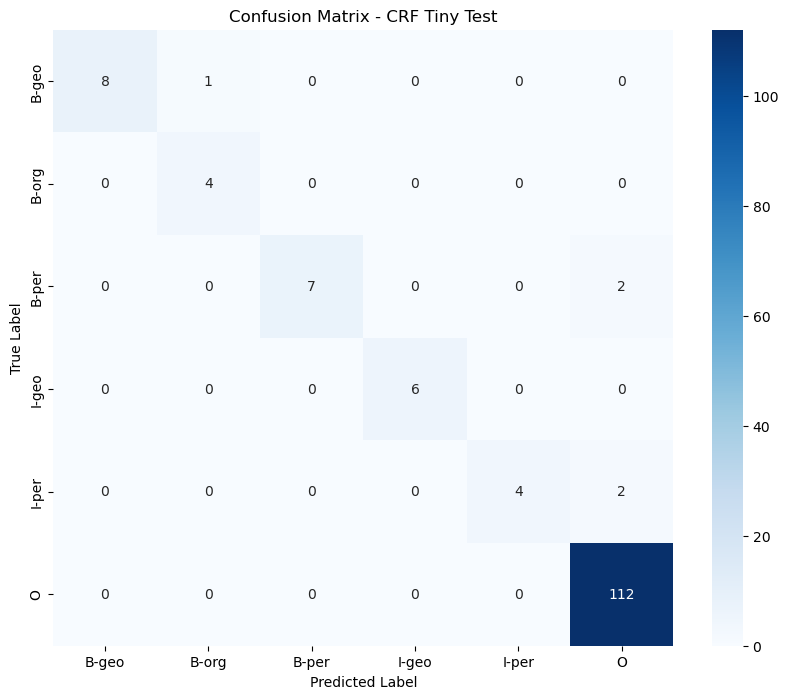

Accuracy on TINY TEST: 0.8529


In [5]:
print("TINY TEST PREDICTIONS (CRF):")
X_tiny = [utils.sent2features(s) for s in tiny_test_sents]
y_tiny_true = [utils.sent2labels(s) for s in tiny_test_sents]
y_tiny_pred = crf.predict(X_tiny)

for i, sent in enumerate(tiny_test_sents):
    words = [w for w, t in sent]
    utils.print_tiny_test_results(words, y_tiny_pred[i])

acc_tiny, _ = utils.evaluate_model(y_tiny_true, y_tiny_pred, model_name="CRF Tiny Test")
print(f"Accuracy on TINY TEST: {acc_tiny:.4f}")